Task 2: Question and Answering with BioASQ

Step1: Load Pretrained Biobert & Datset

In [6]:
!pip install transformers torch numpy lime shap requests

In [12]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("question-answering", model="dmis-lab/biobert-base-cased-v1.1-squad")

Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [15]:
import json
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline
import torch

MODEL_DIR = r"C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert"  # raw string for Windows paths

# load BioBERT from local directory - CRITICAL: local_files_only=True
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_DIR, local_files_only=True)

qa_pipe = pipeline(
    "question-answering",
    model=model,
    tokenizer=tokenizer,
    device=0  # use -1 if no GPU
)

print("BioBERT loaded successfully!")

Some weights of the model checkpoint at C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


BioBERT loaded successfully!


In [18]:
import json

BIOASQ_PATH = r"C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert\BioASQ-test-factoid-6b-1.json"

with open(BIOASQ_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

assert "data" in data and isinstance(data["data"], list)

first_article = data["data"][0]
first_paragraph = first_article["paragraphs"][0]

context = first_paragraph["context"]
first_qa = first_paragraph["qas"][0]
question = first_qa["question"]
qid = first_qa.get("id")

print("ID:", qid)
print("QUESTION:", question)
print("CONTEXT PREVIEW:", context[:300])


ID: 5a6a3335b750ff4455000025_000
QUESTION: Which algorithm is available for computing minimal absent words using external memory?
CONTEXT PREVIEW: emMAW: computing minimal absent words in external memory. Motivation: The biological significance of minimal absent words has been investigated in genomes of organisms from all domains of life. For instance, three minimal absent words of the human genome were found in Ebola virus genomes. There exis


In [19]:
import json

PRED_PATH = "./predictions_biobert_hf.json"

with open(BIOASQ_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

all_predictions = []

for article in data["data"]:
    for para in article["paragraphs"]:
        ctx = para["context"]
        for qa in para["qas"]:
            qid = qa.get("id")
            question = qa["question"]
            # run QA model
            out = qa_pipe({"question": question, "context": ctx})
            all_predictions.append({
                "id": qid,
                "question": question,
                "context": ctx,
                "predictions": [
                    {
                        "answer": out["answer"],
                        "score": float(out["score"]),
                        "context_preview": ctx[:400]
                    }
                ]
            })

with open(PRED_PATH, "w", encoding="utf-8") as f:
    json.dump({"predictions": all_predictions}, f, ensure_ascii=False, indent=2)

print("Saved", len(all_predictions), "BioBERT predictions to", PRED_PATH)


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


Saved 121 BioBERT predictions to ./predictions_biobert_hf.json


Extracting important features using LIME 

In [ ]:
import json
import random
import numpy as np
from lime.lime_text import LimeTextExplainer

PRED_PATH = "./predictions_biobert_hf.json"
SAMPLE_N = 10
MIN_LEN = 10
MAX_CHARS = 400

# ----- load model + predictions -----
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_DIR, local_files_only=True)
qa_pipe = pipeline("question-answering", model=model, tokenizer=tokenizer, device=0)

with open(PRED_PATH, "r", encoding="utf-8") as f:
    preds_file = json.load(f)
all_preds = preds_file["predictions"]

sampled = random.sample(all_preds, k=min(SAMPLE_N, len(all_preds)))
print("Sampled", len(sampled), "examples")

def pick_best_span(pred_entry):
    if not pred_entry.get("predictions"):
        return None
    return max(pred_entry["predictions"], key=lambda x: x["score"])

# LIME explainer
lime_explainer = LimeTextExplainer(class_names=["low_score", "high_score"])

lime_results = []

for ex in sampled:
    qid = ex["id"]
    question = ex["question"]
    raw_ctx = ex.get("context") or (ex["predictions"][0]["context_preview"] if ex.get("predictions") else "")
    if not raw_ctx or len(raw_ctx.strip()) < MIN_LEN:
        continue
    context = raw_ctx[:MAX_CHARS]

    best = pick_best_span(ex)
    if best is None or not best.get("answer"):
        continue
    answer = best["answer"]

    # ----- LIME -----
    def lime_predict(text_list):
        probs = []
        for ctx in text_list:
            out = qa_pipe({"question": question, "context": ctx})
            s = float(out["score"])
            probs.append([1.0 - s, s])
        return np.array(probs)

    exp = lime_explainer.explain_instance(
        context,
        lime_predict,
        num_features=20,
        num_samples=500
    )
    feats = exp.as_list()

    lime_results.append({
        "id": qid,
        "question": question,
        "answer": answer,
        "context": context,
        "lime_words": [w for (w, wgt) in feats],
        "lime_weights": [float(wgt) for (w, wgt) in feats]
    })

print("Got LIME for", len(lime_results), "examples")

with open("./sample10_with_lime.json", "w", encoding="utf-8") as f:
    json.dump({"predictions": lime_results}, f, ensure_ascii=False, indent=2)


Some weights of the model checkpoint at C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Sampled 10 examples


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(
c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(
c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(
c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answer

Got LIME for 10 examples


In [37]:
import json
import numpy as np

# input LIME explanations (from your joint SHAP+LIME run)
LIME_FILE = "./sample10_with_lime.json"

# output aggregated top-k file
OUT_FILE = "./top_lime_10.json"

TOP_K = 5  # number of most important LIME words to keep per example

# ---- load LIME predictions ----
with open(LIME_FILE, "r", encoding="utf-8") as f:
    lime_data = json.load(f)["predictions"]

agg_examples = []

for ex in lime_data:
    words = ex["lime_words"]
    wts = np.array(ex["lime_weights"], dtype=float)

    # indices of top |weight|
    idx = np.argsort(-np.abs(wts))[:TOP_K]

    top_words = [words[i].strip() for i in idx]
    top_weights = [float(wts[i]) for i in idx]

    agg_examples.append({
        "id": ex["id"],
        "question": ex["question"],
        "answer": ex["answer"],
        "context": ex["context"],
        "top_lime_words": top_words,
        "top_lime_weights": top_weights
    })

# ---- save aggregated results ----
with open(OUT_FILE, "w", encoding="utf-8") as f:
    json.dump({"examples": agg_examples}, f, ensure_ascii=False, indent=2)

print(f"Saved top-{TOP_K} LIME words for {len(agg_examples)} examples to {OUT_FILE}")


Saved top-5 LIME words for 10 examples to ./top_lime_10.json


Lime Faithfullness Check

In [41]:
import json
import numpy as np
from lime.lime_text import LimeTextExplainer

# Load your SAVED LIME results
LIME_FILE = "./sample10_with_lime.json"

with open(LIME_FILE, "r", encoding="utf-8") as f:
    lime_data = json.load(f)["predictions"]

def compute_saved_lime_faithfulness(lime_ex_entry, qa_pipe):
    """
    Compute LIME faithfulness using your SAVED lime_words/weights
    """
    question = lime_ex_entry["question"]
    context = lime_ex_entry["context"]
    
    # Re-run LIME with EXACT same parameters
    lime_explainer = LimeTextExplainer(class_names=["low_score", "high_score"])
    
    def lime_predict(text_list):
        probs = []
        for ctx in text_list:
            out = qa_pipe({"question": question, "context": ctx})
            s = float(out["score"])
            probs.append([1.0 - s, s])
        return np.array(probs)
    
    exp = lime_explainer.explain_instance(
        context, lime_predict, num_features=20, num_samples=500
    )
    
    # Handle 1D or 2D local_pred
    if len(exp.local_pred.shape) == 1:
        g_scores = exp.local_pred  # 1D case
    else:
        g_scores = exp.local_pred[:, 1]  # 2D case (high_score class)
    
    # BioBERT true scores (same length as g_scores)
    f_scores = []
    for i in range(len(g_scores)):
        # Use original context score for all (simplified faithfulness)
        out = qa_pipe({"question": question, "context": context})
        f_scores.append(float(out["score"]))
    f_scores = np.array(f_scores)
    
    # Faithfulness metrics
    mse = np.mean((f_scores - g_scores)**2)
    corr = np.corrcoef(f_scores, g_scores)[0,1] if len(f_scores) > 1 else 0.0
    
    # Check if saved LIME words match re-run
    saved_words = lime_ex_entry["lime_words"][:5]
    rerun_feats = exp.as_list()[:5]
    rerun_words = [w for w, _ in rerun_feats]
    words_match = saved_words == rerun_words
    
    return {
        "mse": float(mse),
        "correlation": float(corr),
        "original_score": float(qa_pipe({"question": question, "context": context})["score"]),
        "lime_words_match": words_match,
        "saved_top_words": saved_words,
        "rerun_top_words": rerun_words
    }

# Test on your two specific examples
target_ids = ["5a7d4721faa1ab7d2e000012_000", "5a87ea1861bb38fb2400000d_001"]

for target_id in target_ids:
    example = next((ex for ex in lime_data if ex["id"] == target_id), None)
    if example:
        print(f"\n--- Faithfulness for: {example['question'][:60]}...")
        print(f"   Answer: {example['answer']}")
        faithfulness = compute_saved_lime_faithfulness(example, qa_pipe)
        print(f"MSE: {faithfulness['mse']:.4f} {'✅ GOOD' if faithfulness['mse'] < 0.05 else '⚠️ POOR'}")
        print(f"BioBERT score: {faithfulness['original_score']:.4f}")
        print(f"Saved top-5: {faithfulness['saved_top_words']}")
        print(f"Rerun top-5: {faithfulness['rerun_top_words']}")
    else:
        print(f"ID {target_id} not found in LIME file")



--- Faithfulness for: What does davunetide do to microtubules?...
   Answer: impairments in axonal transport


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


MSE: 0.0001 ✅ GOOD
BioBERT score: 0.1095
Saved top-5: ['Microtubule', 'peptides', 'brain', 'axonal', 'was']
Rerun top-5: [np.str_('Microtubule'), np.str_('peptides'), np.str_('brain'), np.str_('and'), np.str_('molecules')]

--- Faithfulness for: What is a coligo?...
   Answer: L-loop


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


MSE: 0.0120 ✅ GOOD
BioBERT score: 0.0615
Saved top-5: ['coligo', 'coligos', 'oligonucleotides', 'cells', '12']
Rerun top-5: [np.str_('coligo'), np.str_('coligos'), np.str_('of'), np.str_('Circularized'), np.str_('a')]


Ontology Lookup

In [43]:
import json
import requests
import urllib.parse
import time
import numpy as np

# Load your SAVED TOP_LIME file (top_lime_10.json)
TOP_LIME_FILE = "./top_lime_10.json"

with open(TOP_LIME_FILE, "r", encoding="utf-8") as f:
    top_lime_data = json.load(f)["examples"]

# Your target IDs
target_ids = ["5a7d4721faa1ab7d2e000012_000", "5a87ea1861bb38fb2400000d_001"]

# Get examples from top_lime_10.json
examples = []
for target_id in target_ids:
    example = next((ex for ex in top_lime_data if ex["id"] == target_id), None)
    if example:
        examples.append(example)
    else:
        print(f"Warning: ID {target_id} not found in top_lime_10.json")

print(f"Found {len(examples)} examples from top_lime_10.json")

# ----- MeSH lookup helper -----
MESH_LOOKUP_URL = "https://id.nlm.nih.gov/mesh/lookup/descriptor"

def lookup_mesh(term, max_results=3, sleep=0.2):
    params = {"label": term, "match": "contains", "limit": max_results}
    url = MESH_LOOKUP_URL + "?" + urllib.parse.urlencode(params)
    r = requests.get(url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r.status_code != 200:
        return []
    return r.json()

# ----- run lookup -----
grounded_examples = []

for example in examples:
    print(f"\n--- Processing: {example['question'][:60]}...")
    
    grounded_terms = []
    
    for word, weight in zip(example["top_lime_words"], example["top_lime_weights"]):
        term = word.strip()
        if not term:
            continue
        if len(term.split()) > 6:
            continue

        hits = lookup_mesh(term, max_results=3)
        for h in hits:
            grounded_terms.append({
                "token": term,
                "lime_weight": weight,
                "mesh_id": h.get("resource"),
                "mesh_label": h.get("label"),
                "mesh_term": h.get("term")
            })
    
    grounded_example = {
        "id": example["id"],
        "question": example["question"],
        "answer": example["answer"],
        "context": example["context"],
        "top_lime_words": example["top_lime_words"],
        "top_lime_weights": example["top_lime_weights"],
        "grounded_terms": grounded_terms
    }
    
    grounded_examples.append(grounded_example)

# save
OUT_FILE = "./grounded_mesh_lime_two_examples.json"
with open(OUT_FILE, "w", encoding="utf-8") as f:
    json.dump(grounded_examples, f, ensure_ascii=False, indent=2)

print(f"\nSaved grounded MeSH lookup for {len(grounded_examples)} examples to {OUT_FILE}")


Found 2 examples from top_lime_10.json

--- Processing: What does davunetide do to microtubules?...

--- Processing: What is a coligo?...

Saved grounded MeSH lookup for 2 examples to ./grounded_mesh_lime_two_examples.json


Difficulty Modelling

In [57]:
import json, math
from owlready2 import get_ontology, Thing

############################################
# ONTOLOGY LOADING + ADAPTIVE METRICS
############################################

MAX_DEPTH = 0
TOTAL_CLASSES = 0
OBJECT_PROPERTIES = []

def _class_depth_raw(concept) -> int:
    try:
        ancestors = [a for a in concept.ancestors() if isinstance(a, type)]
        if Thing in ancestors:
            ancestors = [a for a in ancestors if a is not Thing]
        return max(len(ancestors), 0)
    except Exception:
        return 0

def _class_depth(concept) -> int:
    return _class_depth_raw(concept)

def load_ontology(owl_path: str):
    print(f"Stage: LOADING ONTOLOGY from '{owl_path}'")
    ont = get_ontology(owl_path).load()
    print("Stage: ONTOLOGY loaded")
    
    global MAX_DEPTH, TOTAL_CLASSES, OBJECT_PROPERTIES
    classes = list(ont.classes())
    TOTAL_CLASSES = len(classes)
    OBJECT_PROPERTIES = list(ont.object_properties())
    
    current_max = 0
    for c in classes[:500]:
        d = _class_depth_raw(c)
        if d > current_max:
            current_max = d
    MAX_DEPTH = current_max if current_max > 0 else 12
    print(f"Stats -> Total Classes: {TOTAL_CLASSES}, Est. Max Depth: {MAX_DEPTH}")
    return ont

def find_concept(ontology, label_or_name: str):
    candidates = list(ontology.search(label=label_or_name))
    if not candidates:
        lower = label_or_name.lower()
        candidates = [
            c for c in ontology.classes()
            if any(str(lbl).lower() == lower for lbl in getattr(c, 'label', []))
        ]
    if candidates:
        return candidates[0]
    try:
        return ontology[label_or_name]
    except Exception:
        return None

def calculate_suitability_score(concept, user_category: str) -> float:
    raw_depth = _class_depth_raw(concept)
    specificity = raw_depth / MAX_DEPTH if MAX_DEPTH > 0 else 0
    
    incoming_links = 0
    for prop in OBJECT_PROPERTIES:
        try:
            if concept in prop.range:
                incoming_links += 1
        except Exception:
            continue
    popularity = incoming_links / TOTAL_CLASSES if TOTAL_CLASSES > 0 else 0
    
    cat = user_category.upper()
    if cat == 'BEGINNER':
        return (0.6 * popularity) + (0.4 * (1.0 - specificity))
    elif cat == 'EXPERT':
        return specificity
    elif cat == 'INTERMEDIATE':
        return 1.0 - abs(specificity - 0.5)
    return 0.0

def get_ancestors(concept, include_self=False):
    ancestors = [a for a in concept.ancestors()
                 if isinstance(a, type) and a is not Thing]
    ancestors_sorted = sorted(ancestors, key=lambda x: _class_depth_raw(x))
    return [concept] + ancestors_sorted if include_self else ancestors_sorted

def select_ancestors(entity_concept, user_category):
    print(f"Stage: SELECT_ANCESTORS for '{getattr(entity_concept,'name',str(entity_concept))}' (User: {user_category})")
    if entity_concept is None:
        return []

    ancestors = get_ancestors(entity_concept)
    
    scored_candidates = []
    for anc in ancestors:
        score = calculate_suitability_score(anc, user_category)
        scored_candidates.append((anc, score))
        
    scored_candidates.sort(key=lambda x: x[1], reverse=True)
    print("** Number of candidates found:", len(scored_candidates))
    
    cat = user_category.upper()
    if cat == 'EXPERT':
        top_k = len(scored_candidates)
    elif cat == 'BEGINNER':
        top_k = max(1, math.ceil(len(scored_candidates) * 0.4))
    elif cat == 'INTERMEDIATE':
        top_k = max(1, math.ceil(len(scored_candidates) * 0.6))
    else:
        top_k = len(scored_candidates)
    
    selected_tuples = scored_candidates[:top_k]

    def label(c):
        return str(getattr(c, 'label', [c.name])[0])

    selected_objs = [obj for obj, _ in selected_tuples]
    selected_objs.sort(key=lambda x: _class_depth_raw(x))
    final_labels = [label(o) for o in selected_objs]

    print(f"Stage: Selected: {final_labels}")
    return final_labels

In [46]:
MESH_OWL_PATH = r"C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert\mesh1.owl"  # adjust to your path

print("Loading MeSH ontology...")
ont = load_ontology(MESH_OWL_PATH)
print("✅ Ontology loaded!")
print(f"   Classes: {TOTAL_CLASSES:,}, Max depth: {MAX_DEPTH}")

Loading MeSH ontology...
Stage: LOADING ONTOLOGY from 'C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert\mesh1.owl'
Stage: ONTOLOGY loaded
Stats -> Total Classes: 305232, Est. Max Depth: 8
✅ Ontology loaded!
   Classes: 305,232, Max depth: 8


In [65]:
import json
import requests
import urllib.parse
import time

# MeSH API URL
MESH_LOOKUP_URL = "https://id.nlm.nih.gov/mesh/lookup/descriptor"

# Your target IDs
target_ids = ["5a7d4721faa1ab7d2e000012_000", "5a87ea1861bb38fb2400000d_001"]

# Load grounded examples
with open("./grounded_mesh_lime_two_examples.json", "r", encoding="utf-8") as f:
    grounded_exs = json.load(f)

# Filter to your target IDs (and keep a stable order)
examples = [ex for ex in grounded_exs if ex["id"] in target_ids]
examples.sort(key=lambda ex: target_ids.index(ex["id"]))
print(f"Processing {len(examples)} examples")

# MeSH URI lookup cache
label_to_uri = {}

def lookup_mesh_descriptor_by_label(label: str, sleep=0.1):
    params = {"label": label, "match": "exact", "limit": 1}
    url = MESH_LOOKUP_URL + "?" + urllib.parse.urlencode(params)
    r = requests.get(url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r.status_code != 200:
        return None
    data = r.json()
    return data[0].get("resource") if data else None

levels = ["BEGINNER", "INTERMEDIATE", "EXPERT"]

for USER_CATEGORY in levels:
    print(f"\n--- Generating {USER_CATEGORY} bundle ---")
    
    for idx, ex in enumerate(examples, start=1):   # idx = 1 for first example, 2 for second
        concepts_for_llm = []
        
        for term in ex["grounded_terms"]:
            mesh_label = term["mesh_label"]
            token = term["token"]
            lw = term["lime_weight"]
            mesh_id = term["mesh_id"]
            
            concept = find_concept(ont, mesh_label)
            if concept is None:
                print(f"Warning: No concept found for '{mesh_label}'")
                continue
            
            # 1) Get difficulty-based ancestors
            anc_labels = select_ancestors(concept, USER_CATEGORY)
            
            # 2) Enrich with MeSH URIs
            anc_enriched = []
            for anc_label in anc_labels:
                if anc_label not in label_to_uri:
                    label_to_uri[anc_label] = lookup_mesh_descriptor_by_label(anc_label)
                anc_uri = label_to_uri[anc_label]
                anc_enriched.append({
                    "label": anc_label,
                    "mesh_id": anc_uri
                })
            
            concepts_for_llm.append({
                "token": token,
                "lime_weight": lw,
                "mesh_id": mesh_id,
                "mesh_label": mesh_label,
                "difficulty_ancestors": anc_labels,
                "difficulty_ancestors_enriched": anc_enriched
            })
        
        bundle = {
            "id": ex["id"],
            "question": ex["question"],
            "answer": ex["answer"],
            "context": ex["context"],
            "user_category": USER_CATEGORY,
            "concepts": concepts_for_llm
        }
        
        # File name: ontology_bundle_<category>_example<idx>.json
        out_path = f"./ontology_bundle_{USER_CATEGORY.lower()}_example{idx}.json"
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(bundle, f, ensure_ascii=False, indent=2)
        
        print(f"  Saved {USER_CATEGORY} bundle for example {idx} -> {out_path}")

print("\nAll bundles generated successfully!")


Processing 2 examples

--- Generating BEGINNER bundle ---
Stage: SELECT_ANCESTORS for 'D008868' (User: BEGINNER)
** Number of candidates found: 9
Stage: Selected: ['Amino Acids, Peptides, and Proteins', 'Macromolecular Substances', 'Polymers', 'Proteins']
Stage: SELECT_ANCESTORS for 'D008869' (User: BEGINNER)
** Number of candidates found: 8
Stage: Selected: ['Amino Acids, Peptides, and Proteins', 'Proteins', 'Nerve Tissue Proteins', 'Cytoskeletal Proteins']
Stage: SELECT_ANCESTORS for 'A11.284.430.214.190.750.585' (User: BEGINNER)
** Number of candidates found: 7
Stage: Selected: ['Cells', 'Cellular Structures', 'Intracellular Space']
Stage: SELECT_ANCESTORS for 'D000602' (User: BEGINNER)
** Number of candidates found: 2
Stage: Selected: ['Amino Acids, Peptides, and Proteins']
Stage: SELECT_ANCESTORS for 'D016229' (User: BEGINNER)
** Number of candidates found: 12
Stage: Selected: ['Amino Acids, Peptides, and Proteins', 'Peptides', 'Proteins', 'Membrane Proteins', 'Amyloid']
Stage: SE

In [ ]:
import requests, time, json

def get_mesh_scope_note(mesh_id: str, sleep=0.1):
    """
    mesh_id: full URI, e.g. 'http://id.nlm.nih.gov/mesh/D002341'
    Returns the English scopeNote string from the preferred concept, or None.
    """
    # 1) descriptor JSON
    short_id = mesh_id.rsplit('/', 1)[-1]
    desc_url = f"https://id.nlm.nih.gov/mesh/{short_id}.json"
    r = requests.get(desc_url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r.status_code != 200:
        return None
    desc = r.json()

    pref = desc.get("preferredConcept")
    if not pref:
        return None

    # handle either dict or URI string
    if isinstance(pref, dict):
        concept_uri = pref.get("resource") or pref.get("@id")
    else:
        concept_uri = str(pref)
    if not concept_uri:
        return None

    # 2) concept JSON
    cid = concept_uri.rsplit('/', 1)[-1]
    concept_url = f"https://id.nlm.nih.gov/mesh/{cid}.json"
    r2 = requests.get(concept_url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r2.status_code != 200:
        return None
    concept = r2.json()

    scope = concept.get("scopeNote")
    # MeSH RDF gives a dict, not a list, here
    if isinstance(scope, dict):
        return scope.get("@value")
    if isinstance(scope, list) and scope:
        return scope[0].get("@value")
    return None


In [86]:
bundle_paths = [
    "./ontology_bundle_beginner_example2.json",
    "./ontology_bundle_intermediate_example2.json",
    "./ontology_bundle_expert_example2.json",
]

for PATH in bundle_paths:
    print("Updating", PATH)
    with open(PATH, "r", encoding="utf-8") as f:
        ex = json.load(f)

    uri_to_def = {}   # cache URI -> definition

    for c in ex.get("concepts", []):
        # 1) main node definition
        mid = c["mesh_id"]
        if mid not in uri_to_def:
            uri_to_def[mid] = get_mesh_scope_note(mid)
        c["mesh_definition"] = uri_to_def[mid]

        # 2) ancestors' definitions
        for anc in c.get("difficulty_ancestors_enriched", []):
            amid = anc.get("mesh_id")
            if not amid:
                anc["mesh_definition"] = None
                continue
            if amid not in uri_to_def:
                uri_to_def[amid] = get_mesh_scope_note(amid)
            anc["mesh_definition"] = uri_to_def[amid]

    with open(PATH, "w", encoding="utf-8") as f:
        json.dump(ex, f, ensure_ascii=False, indent=2)

    print("  -> mesh_definition added for main + ancestors")


Updating ./ontology_bundle_beginner_example2.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_intermediate_example2.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_expert_example2.json
  -> mesh_definition added for main + ancestors


In [85]:
bundle_paths = [
    "./ontology_bundle_beginner_example1.json",
    "./ontology_bundle_intermediate_example1.json",
    "./ontology_bundle_expert_example1.json",
    "./ontology_bundle_beginner_example2.json",
    "./"
]

for PATH in bundle_paths:
    print("Updating", PATH)
    with open(PATH, "r", encoding="utf-8") as f:
        ex = json.load(f)

    uri_to_def = {}   # cache URI -> definition

    for c in ex.get("concepts", []):
        # 1) main node definition
        mid = c["mesh_id"]
        if mid not in uri_to_def:
            uri_to_def[mid] = get_mesh_scope_note(mid)
        c["mesh_definition"] = uri_to_def[mid]

        # 2) ancestors' definitions
        for anc in c.get("difficulty_ancestors_enriched", []):
            amid = anc.get("mesh_id")
            if not amid:
                anc["mesh_definition"] = None
                continue
            if amid not in uri_to_def:
                uri_to_def[amid] = get_mesh_scope_note(amid)
            anc["mesh_definition"] = uri_to_def[amid]

    with open(PATH, "w", encoding="utf-8") as f:
        json.dump(ex, f, ensure_ascii=False, indent=2)

    print("  -> mesh_definition added for main + ancestors")


Updating ./ontology_bundle_beginner_example1.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_intermediate_example1.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_expert_example1.json
  -> mesh_definition added for main + ancestors


In [93]:
import json
import os

# Explicit list of your files
files = [
    "./ontology_bundle_beginner_example1.json",
    "./ontology_bundle_beginner_example2.json",
    "./ontology_bundle_intermediate_example1.json",
    "./ontology_bundle_intermediate_example2.json",
    "./ontology_bundle_expert_example1.json",
    "./ontology_bundle_expert_example2.json",
]

for file_path in files:
    filename = os.path.basename(file_path)

    print("\n" + "="*90)
    print(f"FILE: {filename}")
    print("="*90)

    # Load JSON file
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Print main fields
    print(f"ID: {data.get('id')}")
    print(f"Question: {data.get('question')}")
    print(f"Answer: {data.get('answer')}")
    print(f"Context: {data.get('context')}")
    print(f"User Category: {data.get('user_category')}\n")

    # Print concepts
    print("Concepts and Definitions:")
    print("-" * 40)

    for concept in data.get("concepts", []):
        print(f"Token: {concept.get('token')}")
        print(f"Label: {concept.get('mesh_label')}")
        print(f"Definition: {concept.get('mesh_definition')}\n")

    print("\n")



FILE: ontology_bundle_beginner_example1.json
ID: 5a7d4721faa1ab7d2e000012_000
Question: What does davunetide do to microtubules?
Answer: impairments in axonal transport
Context: Microtubule-stabilizing peptides and small molecules protecting axonal transport and brain function: focus on davunetide (NAP). This review focuses on the therapeutic effects and mechanisms of action of NAP (davunetide), an eight amino acid snippet derived from activity-dependent neuroprotective protein (ADNP) which was discovered in our laboratory. We have recently described the effects of NAP in
User Category: BEGINNER

Concepts and Definitions:
----------------------------------------
Token: Microtubule
Label: Microtubule Proteins
Definition: Proteins found in the microtubules.

Token: Microtubule
Label: Microtubule-Associated Proteins
Definition: High molecular weight proteins found in the MICROTUBULES of the cytoskeletal system. Under certain conditions they are required for TUBULIN assembly into the micr

In [ ]:
import json
from io import StringIO
import os

def load_bundle(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def build_structured_bundle_text(ex, label):
    buf = StringIO()

    buf.write(f"\n===== {label} =====\n\n")
    buf.write(f"Question: {ex['question']}\n")
    buf.write(f"Answer  : {ex['answer']}\n")
    buf.write(f"Context : {ex['context']}\n")
    buf.write("\nConcepts (grouped by MeSH label):\n\n")

    # Group by mesh_label
    by_label = {}
    for c in ex["concepts"]:
        key = c["mesh_label"]
        by_label.setdefault(key, []).append(c)

    for mesh_label, items in by_label.items():
        base = items[0]  # same label → same mesh_definition
        tokens = sorted({c["token"] for c in items})

        buf.write(f"== MeSH concept: {mesh_label} ==\n")
        buf.write(f"Tokens : {', '.join(tokens)}\n")
        buf.write("Definition:\n")
        buf.write(f"  {base['mesh_definition']}\n")

        # Collect unique ancestors across all items for this label
        ancestor_defs = {}
        for c in items:
            for anc in c.get("difficulty_ancestors_enriched", []):
                ancestor_defs[anc["label"]] = anc["mesh_definition"]

        if ancestor_defs:
            buf.write("Ancestors:\n")
            for anc_label, anc_def in ancestor_defs.items():
                buf.write(f"  - {anc_label}: {anc_def}\n")
        buf.write("\n")  # blank line

    return buf.getvalue()


# All 6 example files
files = [
    "./ontology_bundle_beginner_example1.json",
    "./ontology_bundle_beginner_example2.json",
    "./ontology_bundle_intermediate_example1.json",
    "./ontology_bundle_intermediate_example2.json",
    "./ontology_bundle_expert_example1.json",
    "./ontology_bundle_expert_example2.json",
]

# Group bundles by question (example 1 vs example 2)
by_question = {}  # question text -> list of (bundle_dict)
for path in files:
    ex = load_bundle(path)
    q = ex["question"]
    by_question.setdefault(q, []).append(ex)

# Nice order for categories
cat_order = ["BEGINNER", "INTERMEDIATE", "EXPERT"]

output_dir = "./"
os.makedirs(output_dir, exist_ok=True)

# For each question group, build one text file
for idx, (question, bundle_list) in enumerate(sorted(by_question.items()), start=1):
    # Sort bundles by user_category so they appear BEGINNER → INTERMEDIATE → EXPERT
    bundle_list_sorted = sorted(
        bundle_list,
        key=lambda ex: cat_order.index(ex["user_category"])
    )

    buf = StringIO()
    for ex in bundle_list_sorted:
        label = f"{ex['user_category']} CATEGORY"
        buf.write(build_structured_bundle_text(ex, label))

    # Save as separate file per example
    out_path = os.path.join(output_dir, f"ontology_bundles_example{idx}_structured.txt")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(buf.getvalue())

    print(f"Saved: {out_path}")

Saved: ./ontology_bundles_example1_structured.txt
Saved: ./ontology_bundles_example2_structured.txt


Generating Explanations

1. Without Ontology Grounding: 

In [102]:
import requests

# -------- OLLAMA CONFIG --------
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma2:2b"

def call_ollama(prompt, model_name=MODEL_NAME, temperature=0.3):
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    resp = requests.post(OLLAMA_URL, json=payload)
    resp.raise_for_status()
    data = resp.json()
    return data.get("response", "").strip()


# -------- PUT YOUR INPUTS HERE --------
question = """What is a coligo?"""
answer   = """L-loop"""
context  = """RNA polymerase III initiation on coligo DNA templates containing loops of variable sequence, size and nucleotide chemistry. Circularized oligonucleotides, or coligos, were previously found to serve as RNA polymerase III templates in vitro and in human tissue culture cells. Here we randomized the 12-nucleotide larger loop (L-loop) of a well characterized coligo and found unexpectedly that..."""
# Replace these 3 strings with any question/answer/context you want


# -------- PROMPT BUILDING --------
def build_plain_prompt(level, question, answer, context):
    if level == "BEGINNER":
        audience = "someone with very little biology or medicine background"
        style = (
            "Use simple language and short sentences.\n"
            "Avoid jargon unless absolutely necessary."
        )
        length = "Write 2–3 short sentences."
    else:  # EXPERT
        audience = "an expert biomedical reader"
        style = (
            "You may use technical terminology and be concise and precise."
        )
        length = "Write a detailed paragraph of 5–7 sentences."

    prompt = f"""You are a helpful biomedical tutor.

Question:
{question}

Correct answer:
{answer}

Context:
{context}

Task:
Explain why this answer is correct, assuming your reader is {audience}.
{style}
{length}
Do not mention that you are an AI model; only give the explanation."""
    return prompt


# -------- GENERATE EXPLANATIONS --------
beg_prompt = build_plain_prompt("BEGINNER", question, answer, context)
exp_prompt = build_plain_prompt("EXPERT",   question, answer, context)

beg_expl = call_ollama(beg_prompt)
exp_expl = call_ollama(exp_prompt)

print("\n===== BEGINNER EXPLANATION =====\n")
print(beg_expl)

print("\n===== EXPERT EXPLANATION =====\n")
print(exp_expl)



===== BEGINNER EXPLANATION =====

A coligo is a special type of DNA sequence, like a mini-DNA puzzle.  Scientists use these "loops" to help RNA polymerase III make RNA, which is important for making proteins in our bodies.

===== EXPERT EXPLANATION =====

The term "coligo" refers to a circularized oligonucleotide, often referred to as a "L-loop," which serves as a template for RNA polymerase III in vitro and within cellular environments.  These coligos typically possess a defined loop structure, characterized by a 12-nucleotide sequence with a variable composition of nucleotides. The L-loop's unique structural properties allow it to interact with RNA polymerase III, facilitating the initiation of transcription.  The study described explores the impact of randomizing the L-loop in coligos on their ability to drive transcription. By altering the loop structure, researchers aim to understand how specific loop features influence the efficiency and specificity of transcription initiation.


In [108]:
import requests

# -------- OLLAMA CONFIG --------
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma2:2b"

def call_ollama(prompt, model_name=MODEL_NAME, temperature=0.3):
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    resp = requests.post(OLLAMA_URL, json=payload)
    resp.raise_for_status()
    data = resp.json()
    return data.get("response", "").strip()


# -------- PUT YOUR INPUTS HERE --------
question = """What does davunetide do to microtubules?"""
answer   = """impairments in axonal transport"""
context  = """Microtubule-stabilizing peptides and small molecules protecting axonal transport and brain function: focus on davunetide (NAP). This review focuses on the therapeutic effects and mechanisms of action of NAP (davunetide), an eight amino acid snippet derived from activity-dependent neuroprotective protein (ADNP) which was discovered in our laboratory. We have recently described the effects of NAP in..."""
# Replace these 3 strings with any question/answer/context you want


# -------- PROMPT BUILDING --------
def build_plain_prompt(level, question, answer, context):
    if level == "BEGINNER":
        audience = "someone with very little biology or medicine background"
        style = (
            "Use simple language and short sentences.\n"
            "Avoid jargon unless absolutely necessary."
        )
        length = "Write 2–3 short sentences."
    else:  # EXPERT
        audience = "an expert biomedical reader"
        style = (
            "You may use technical terminology and be concise and precise."
        )
        length = "Write a detailed paragraph of 5–7 sentences."

    prompt = f"""You are a helpful biomedical tutor.

Question:
{question}

Correct answer:
{answer}

Context:
{context}

Task:
Explain why this answer is correct, assuming your reader is {audience}.
{style}
{length}
Do not mention that you are an AI model; only give the explanation."""
    return prompt


# -------- GENERATE EXPLANATIONS --------
beg_prompt = build_plain_prompt("BEGINNER", question, answer, context)
exp_prompt = build_plain_prompt("EXPERT",   question, answer, context)

beg_expl = call_ollama(beg_prompt)
exp_expl = call_ollama(exp_prompt)

print("\n===== BEGINNER EXPLANATION =====\n")
print(beg_expl)

print("\n===== EXPERT EXPLANATION =====\n")
print(exp_expl)



===== BEGINNER EXPLANATION =====

Davunetide helps keep tiny tubes called microtubules strong.  These tubes help carry important things around a cell, especially in our brain and nerves. Davunetide's ability to do this is what makes it helpful for some medical conditions.

===== EXPERT EXPLANATION =====

Davunetide's mechanism of action primarily involves impairing axonal transport, specifically by targeting microtubules.  This peptide acts as a modulator of microtubule dynamics, stabilizing them in a manner that disrupts normal axonal transport pathways.  The disruption of these pathways leads to impairments in the delivery and degradation of essential cargo molecules, such as neurotransmitters and organelles, within neurons. This ultimately contributes to various neurological conditions characterized by impaired neuronal function and communication. Davunetide's ability to manipulate microtubule dynamics offers a potential avenue for therapeutic interventions aimed at restoring axona

Generating Explanations using Ontology

Task 2: Question and Answering with BioASQ

Step1: Load Pretrained Biobert & Datset

In [ ]:
!pip install transformers torch numpy lime shap requests

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("question-answering", model="dmis-lab/biobert-base-cased-v1.1-squad")

Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [ ]:
import json
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline
import torch

MODEL_DIR = r"C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert"  # raw string for Windows paths

# load BioBERT from local directory - CRITICAL: local_files_only=True
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_DIR, local_files_only=True)

qa_pipe = pipeline(
    "question-answering",
    model=model,
    tokenizer=tokenizer,
    device=0  # use -1 if no GPU
)

print("BioBERT loaded successfully!")

Some weights of the model checkpoint at C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


BioBERT loaded successfully!


In [ ]:
import json

BIOASQ_PATH = r"C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert\BioASQ-test-factoid-6b-1.json"

with open(BIOASQ_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

assert "data" in data and isinstance(data["data"], list)

first_article = data["data"][0]
first_paragraph = first_article["paragraphs"][0]

context = first_paragraph["context"]
first_qa = first_paragraph["qas"][0]
question = first_qa["question"]
qid = first_qa.get("id")

print("ID:", qid)
print("QUESTION:", question)
print("CONTEXT PREVIEW:", context[:300])


ID: 5a6a3335b750ff4455000025_000
QUESTION: Which algorithm is available for computing minimal absent words using external memory?
CONTEXT PREVIEW: emMAW: computing minimal absent words in external memory. Motivation: The biological significance of minimal absent words has been investigated in genomes of organisms from all domains of life. For instance, three minimal absent words of the human genome were found in Ebola virus genomes. There exis


In [ ]:
import json

PRED_PATH = "./predictions_biobert_hf.json"

with open(BIOASQ_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

all_predictions = []

for article in data["data"]:
    for para in article["paragraphs"]:
        ctx = para["context"]
        for qa in para["qas"]:
            qid = qa.get("id")
            question = qa["question"]
            # run QA model
            out = qa_pipe({"question": question, "context": ctx})
            all_predictions.append({
                "id": qid,
                "question": question,
                "context": ctx,
                "predictions": [
                    {
                        "answer": out["answer"],
                        "score": float(out["score"]),
                        "context_preview": ctx[:400]
                    }
                ]
            })

with open(PRED_PATH, "w", encoding="utf-8") as f:
    json.dump({"predictions": all_predictions}, f, ensure_ascii=False, indent=2)

print("Saved", len(all_predictions), "BioBERT predictions to", PRED_PATH)


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


Saved 121 BioBERT predictions to ./predictions_biobert_hf.json


Extracting important features using LIME 

In [ ]:
import json
import random
import numpy as np
from lime.lime_text import LimeTextExplainer

PRED_PATH = "./predictions_biobert_hf.json"
SAMPLE_N = 10
MIN_LEN = 10
MAX_CHARS = 400

# ----- load model + predictions -----
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_DIR, local_files_only=True)
qa_pipe = pipeline("question-answering", model=model, tokenizer=tokenizer, device=0)

with open(PRED_PATH, "r", encoding="utf-8") as f:
    preds_file = json.load(f)
all_preds = preds_file["predictions"]

sampled = random.sample(all_preds, k=min(SAMPLE_N, len(all_preds)))
print("Sampled", len(sampled), "examples")

def pick_best_span(pred_entry):
    if not pred_entry.get("predictions"):
        return None
    return max(pred_entry["predictions"], key=lambda x: x["score"])

# LIME explainer
lime_explainer = LimeTextExplainer(class_names=["low_score", "high_score"])

lime_results = []

for ex in sampled:
    qid = ex["id"]
    question = ex["question"]
    raw_ctx = ex.get("context") or (ex["predictions"][0]["context_preview"] if ex.get("predictions") else "")
    if not raw_ctx or len(raw_ctx.strip()) < MIN_LEN:
        continue
    context = raw_ctx[:MAX_CHARS]

    best = pick_best_span(ex)
    if best is None or not best.get("answer"):
        continue
    answer = best["answer"]

    # ----- LIME -----
    def lime_predict(text_list):
        probs = []
        for ctx in text_list:
            out = qa_pipe({"question": question, "context": ctx})
            s = float(out["score"])
            probs.append([1.0 - s, s])
        return np.array(probs)

    exp = lime_explainer.explain_instance(
        context,
        lime_predict,
        num_features=20,
        num_samples=500
    )
    feats = exp.as_list()

    lime_results.append({
        "id": qid,
        "question": question,
        "answer": answer,
        "context": context,
        "lime_words": [w for (w, wgt) in feats],
        "lime_weights": [float(wgt) for (w, wgt) in feats]
    })

print("Got LIME for", len(lime_results), "examples")

with open("./sample10_with_lime.json", "w", encoding="utf-8") as f:
    json.dump({"predictions": lime_results}, f, ensure_ascii=False, indent=2)


Some weights of the model checkpoint at C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Sampled 10 examples


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(
c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(
c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(
c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answer

Got LIME for 10 examples


In [ ]:
import json
import numpy as np

# input LIME explanations (from your joint SHAP+LIME run)
LIME_FILE = "./sample10_with_lime.json"

# output aggregated top-k file
OUT_FILE = "./top_lime_10.json"

TOP_K = 5  # number of most important LIME words to keep per example

# ---- load LIME predictions ----
with open(LIME_FILE, "r", encoding="utf-8") as f:
    lime_data = json.load(f)["predictions"]

agg_examples = []

for ex in lime_data:
    words = ex["lime_words"]
    wts = np.array(ex["lime_weights"], dtype=float)

    # indices of top |weight|
    idx = np.argsort(-np.abs(wts))[:TOP_K]

    top_words = [words[i].strip() for i in idx]
    top_weights = [float(wts[i]) for i in idx]

    agg_examples.append({
        "id": ex["id"],
        "question": ex["question"],
        "answer": ex["answer"],
        "context": ex["context"],
        "top_lime_words": top_words,
        "top_lime_weights": top_weights
    })

# ---- save aggregated results ----
with open(OUT_FILE, "w", encoding="utf-8") as f:
    json.dump({"examples": agg_examples}, f, ensure_ascii=False, indent=2)

print(f"Saved top-{TOP_K} LIME words for {len(agg_examples)} examples to {OUT_FILE}")


Saved top-5 LIME words for 10 examples to ./top_lime_10.json


Lime Faithfullness Check

In [ ]:
import json
import numpy as np
from lime.lime_text import LimeTextExplainer

# Load your SAVED LIME results
LIME_FILE = "./sample10_with_lime.json"

with open(LIME_FILE, "r", encoding="utf-8") as f:
    lime_data = json.load(f)["predictions"]

def compute_saved_lime_faithfulness(lime_ex_entry, qa_pipe):
    """
    Compute LIME faithfulness using your SAVED lime_words/weights
    """
    question = lime_ex_entry["question"]
    context = lime_ex_entry["context"]
    
    # Re-run LIME with EXACT same parameters
    lime_explainer = LimeTextExplainer(class_names=["low_score", "high_score"])
    
    def lime_predict(text_list):
        probs = []
        for ctx in text_list:
            out = qa_pipe({"question": question, "context": ctx})
            s = float(out["score"])
            probs.append([1.0 - s, s])
        return np.array(probs)
    
    exp = lime_explainer.explain_instance(
        context, lime_predict, num_features=20, num_samples=500
    )
    
    # Handle 1D or 2D local_pred
    if len(exp.local_pred.shape) == 1:
        g_scores = exp.local_pred  # 1D case
    else:
        g_scores = exp.local_pred[:, 1]  # 2D case (high_score class)
    
    # BioBERT true scores (same length as g_scores)
    f_scores = []
    for i in range(len(g_scores)):
        # Use original context score for all (simplified faithfulness)
        out = qa_pipe({"question": question, "context": context})
        f_scores.append(float(out["score"]))
    f_scores = np.array(f_scores)
    
    # Faithfulness metrics
    mse = np.mean((f_scores - g_scores)**2)
    corr = np.corrcoef(f_scores, g_scores)[0,1] if len(f_scores) > 1 else 0.0
    
    # Check if saved LIME words match re-run
    saved_words = lime_ex_entry["lime_words"][:5]
    rerun_feats = exp.as_list()[:5]
    rerun_words = [w for w, _ in rerun_feats]
    words_match = saved_words == rerun_words
    
    return {
        "mse": float(mse),
        "correlation": float(corr),
        "original_score": float(qa_pipe({"question": question, "context": context})["score"]),
        "lime_words_match": words_match,
        "saved_top_words": saved_words,
        "rerun_top_words": rerun_words
    }

# Test on your two specific examples
target_ids = ["5a7d4721faa1ab7d2e000012_000", "5a87ea1861bb38fb2400000d_001"]

for target_id in target_ids:
    example = next((ex for ex in lime_data if ex["id"] == target_id), None)
    if example:
        print(f"\n--- Faithfulness for: {example['question'][:60]}...")
        print(f"   Answer: {example['answer']}")
        faithfulness = compute_saved_lime_faithfulness(example, qa_pipe)
        print(f"MSE: {faithfulness['mse']:.4f} {'✅ GOOD' if faithfulness['mse'] < 0.05 else '⚠️ POOR'}")
        print(f"BioBERT score: {faithfulness['original_score']:.4f}")
        print(f"Saved top-5: {faithfulness['saved_top_words']}")
        print(f"Rerun top-5: {faithfulness['rerun_top_words']}")
    else:
        print(f"ID {target_id} not found in LIME file")



--- Faithfulness for: What does davunetide do to microtubules?...
   Answer: impairments in axonal transport


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


MSE: 0.0001 ✅ GOOD
BioBERT score: 0.1095
Saved top-5: ['Microtubule', 'peptides', 'brain', 'axonal', 'was']
Rerun top-5: [np.str_('Microtubule'), np.str_('peptides'), np.str_('brain'), np.str_('and'), np.str_('molecules')]

--- Faithfulness for: What is a coligo?...
   Answer: L-loop


c:\Users\anush\anaconda3main\Lib\site-packages\transformers\pipelines\question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


MSE: 0.0120 ✅ GOOD
BioBERT score: 0.0615
Saved top-5: ['coligo', 'coligos', 'oligonucleotides', 'cells', '12']
Rerun top-5: [np.str_('coligo'), np.str_('coligos'), np.str_('of'), np.str_('Circularized'), np.str_('a')]


Ontology Lookup

In [ ]:
import json
import requests
import urllib.parse
import time
import numpy as np

# Load your SAVED TOP_LIME file (top_lime_10.json)
TOP_LIME_FILE = "./top_lime_10.json"

with open(TOP_LIME_FILE, "r", encoding="utf-8") as f:
    top_lime_data = json.load(f)["examples"]

# Your target IDs
target_ids = ["5a7d4721faa1ab7d2e000012_000", "5a87ea1861bb38fb2400000d_001"]

# Get examples from top_lime_10.json
examples = []
for target_id in target_ids:
    example = next((ex for ex in top_lime_data if ex["id"] == target_id), None)
    if example:
        examples.append(example)
    else:
        print(f"Warning: ID {target_id} not found in top_lime_10.json")

print(f"Found {len(examples)} examples from top_lime_10.json")

# ----- MeSH lookup helper -----
MESH_LOOKUP_URL = "https://id.nlm.nih.gov/mesh/lookup/descriptor"

def lookup_mesh(term, max_results=3, sleep=0.2):
    params = {"label": term, "match": "contains", "limit": max_results}
    url = MESH_LOOKUP_URL + "?" + urllib.parse.urlencode(params)
    r = requests.get(url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r.status_code != 200:
        return []
    return r.json()

# ----- run lookup -----
grounded_examples = []

for example in examples:
    print(f"\n--- Processing: {example['question'][:60]}...")
    
    grounded_terms = []
    
    for word, weight in zip(example["top_lime_words"], example["top_lime_weights"]):
        term = word.strip()
        if not term:
            continue
        if len(term.split()) > 6:
            continue

        hits = lookup_mesh(term, max_results=3)
        for h in hits:
            grounded_terms.append({
                "token": term,
                "lime_weight": weight,
                "mesh_id": h.get("resource"),
                "mesh_label": h.get("label"),
                "mesh_term": h.get("term")
            })
    
    grounded_example = {
        "id": example["id"],
        "question": example["question"],
        "answer": example["answer"],
        "context": example["context"],
        "top_lime_words": example["top_lime_words"],
        "top_lime_weights": example["top_lime_weights"],
        "grounded_terms": grounded_terms
    }
    
    grounded_examples.append(grounded_example)

# save
OUT_FILE = "./grounded_mesh_lime_two_examples.json"
with open(OUT_FILE, "w", encoding="utf-8") as f:
    json.dump(grounded_examples, f, ensure_ascii=False, indent=2)

print(f"\nSaved grounded MeSH lookup for {len(grounded_examples)} examples to {OUT_FILE}")


Found 2 examples from top_lime_10.json

--- Processing: What does davunetide do to microtubules?...

--- Processing: What is a coligo?...

Saved grounded MeSH lookup for 2 examples to ./grounded_mesh_lime_two_examples.json


Difficulty Modelling

In [ ]:
import json, math
from owlready2 import get_ontology, Thing

############################################
# ONTOLOGY LOADING + ADAPTIVE METRICS
############################################

MAX_DEPTH = 0
TOTAL_CLASSES = 0
OBJECT_PROPERTIES = []

def _class_depth_raw(concept) -> int:
    try:
        ancestors = [a for a in concept.ancestors() if isinstance(a, type)]
        if Thing in ancestors:
            ancestors = [a for a in ancestors if a is not Thing]
        return max(len(ancestors), 0)
    except Exception:
        return 0

def _class_depth(concept) -> int:
    return _class_depth_raw(concept)

def load_ontology(owl_path: str):
    print(f"Stage: LOADING ONTOLOGY from '{owl_path}'")
    ont = get_ontology(owl_path).load()
    print("Stage: ONTOLOGY loaded")
    
    global MAX_DEPTH, TOTAL_CLASSES, OBJECT_PROPERTIES
    classes = list(ont.classes())
    TOTAL_CLASSES = len(classes)
    OBJECT_PROPERTIES = list(ont.object_properties())
    
    current_max = 0
    for c in classes[:500]:
        d = _class_depth_raw(c)
        if d > current_max:
            current_max = d
    MAX_DEPTH = current_max if current_max > 0 else 12
    print(f"Stats -> Total Classes: {TOTAL_CLASSES}, Est. Max Depth: {MAX_DEPTH}")
    return ont

def find_concept(ontology, label_or_name: str):
    candidates = list(ontology.search(label=label_or_name))
    if not candidates:
        lower = label_or_name.lower()
        candidates = [
            c for c in ontology.classes()
            if any(str(lbl).lower() == lower for lbl in getattr(c, 'label', []))
        ]
    if candidates:
        return candidates[0]
    try:
        return ontology[label_or_name]
    except Exception:
        return None

def calculate_suitability_score(concept, user_category: str) -> float:
    raw_depth = _class_depth_raw(concept)
    specificity = raw_depth / MAX_DEPTH if MAX_DEPTH > 0 else 0
    
    incoming_links = 0
    for prop in OBJECT_PROPERTIES:
        try:
            if concept in prop.range:
                incoming_links += 1
        except Exception:
            continue
    popularity = incoming_links / TOTAL_CLASSES if TOTAL_CLASSES > 0 else 0
    
    cat = user_category.upper()
    if cat == 'BEGINNER':
        return (0.6 * popularity) + (0.4 * (1.0 - specificity))
    elif cat == 'EXPERT':
        return specificity
    elif cat == 'INTERMEDIATE':
        return 1.0 - abs(specificity - 0.5)
    return 0.0

def get_ancestors(concept, include_self=False):
    ancestors = [a for a in concept.ancestors()
                 if isinstance(a, type) and a is not Thing]
    ancestors_sorted = sorted(ancestors, key=lambda x: _class_depth_raw(x))
    return [concept] + ancestors_sorted if include_self else ancestors_sorted

def select_ancestors(entity_concept, user_category):
    print(f"Stage: SELECT_ANCESTORS for '{getattr(entity_concept,'name',str(entity_concept))}' (User: {user_category})")
    if entity_concept is None:
        return []

    ancestors = get_ancestors(entity_concept)
    
    scored_candidates = []
    for anc in ancestors:
        score = calculate_suitability_score(anc, user_category)
        scored_candidates.append((anc, score))
        
    scored_candidates.sort(key=lambda x: x[1], reverse=True)
    print("** Number of candidates found:", len(scored_candidates))
    
    cat = user_category.upper()
    if cat == 'EXPERT':
        top_k = len(scored_candidates)
    elif cat == 'BEGINNER':
        top_k = max(1, math.ceil(len(scored_candidates) * 0.4))
    elif cat == 'INTERMEDIATE':
        top_k = max(1, math.ceil(len(scored_candidates) * 0.6))
    else:
        top_k = len(scored_candidates)
    
    selected_tuples = scored_candidates[:top_k]

    def label(c):
        return str(getattr(c, 'label', [c.name])[0])

    selected_objs = [obj for obj, _ in selected_tuples]
    selected_objs.sort(key=lambda x: _class_depth_raw(x))
    final_labels = [label(o) for o in selected_objs]

    print(f"Stage: Selected: {final_labels}")
    return final_labels

In [ ]:
MESH_OWL_PATH = r"C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert\mesh1.owl"  # adjust to your path

print("Loading MeSH ontology...")
ont = load_ontology(MESH_OWL_PATH)
print("✅ Ontology loaded!")
print(f"   Classes: {TOTAL_CLASSES:,}, Max depth: {MAX_DEPTH}")

Loading MeSH ontology...
Stage: LOADING ONTOLOGY from 'C:\Users\anush\Documents\Sem 7\BTP\xai\task2\biobert\mesh1.owl'
Stage: ONTOLOGY loaded
Stats -> Total Classes: 305232, Est. Max Depth: 8
✅ Ontology loaded!
   Classes: 305,232, Max depth: 8


In [ ]:
import json
import requests
import urllib.parse
import time

# MeSH API URL
MESH_LOOKUP_URL = "https://id.nlm.nih.gov/mesh/lookup/descriptor"

# Your target IDs
target_ids = ["5a7d4721faa1ab7d2e000012_000", "5a87ea1861bb38fb2400000d_001"]

# Load grounded examples
with open("./grounded_mesh_lime_two_examples.json", "r", encoding="utf-8") as f:
    grounded_exs = json.load(f)

# Filter to your target IDs (and keep a stable order)
examples = [ex for ex in grounded_exs if ex["id"] in target_ids]
examples.sort(key=lambda ex: target_ids.index(ex["id"]))
print(f"Processing {len(examples)} examples")

# MeSH URI lookup cache
label_to_uri = {}

def lookup_mesh_descriptor_by_label(label: str, sleep=0.1):
    params = {"label": label, "match": "exact", "limit": 1}
    url = MESH_LOOKUP_URL + "?" + urllib.parse.urlencode(params)
    r = requests.get(url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r.status_code != 200:
        return None
    data = r.json()
    return data[0].get("resource") if data else None

levels = ["BEGINNER", "INTERMEDIATE", "EXPERT"]

for USER_CATEGORY in levels:
    print(f"\n--- Generating {USER_CATEGORY} bundle ---")
    
    for idx, ex in enumerate(examples, start=1):   # idx = 1 for first example, 2 for second
        concepts_for_llm = []
        
        for term in ex["grounded_terms"]:
            mesh_label = term["mesh_label"]
            token = term["token"]
            lw = term["lime_weight"]
            mesh_id = term["mesh_id"]
            
            concept = find_concept(ont, mesh_label)
            if concept is None:
                print(f"Warning: No concept found for '{mesh_label}'")
                continue
            
            # 1) Get difficulty-based ancestors
            anc_labels = select_ancestors(concept, USER_CATEGORY)
            
            # 2) Enrich with MeSH URIs
            anc_enriched = []
            for anc_label in anc_labels:
                if anc_label not in label_to_uri:
                    label_to_uri[anc_label] = lookup_mesh_descriptor_by_label(anc_label)
                anc_uri = label_to_uri[anc_label]
                anc_enriched.append({
                    "label": anc_label,
                    "mesh_id": anc_uri
                })
            
            concepts_for_llm.append({
                "token": token,
                "lime_weight": lw,
                "mesh_id": mesh_id,
                "mesh_label": mesh_label,
                "difficulty_ancestors": anc_labels,
                "difficulty_ancestors_enriched": anc_enriched
            })
        
        bundle = {
            "id": ex["id"],
            "question": ex["question"],
            "answer": ex["answer"],
            "context": ex["context"],
            "user_category": USER_CATEGORY,
            "concepts": concepts_for_llm
        }
        
        # File name: ontology_bundle_<category>_example<idx>.json
        out_path = f"./ontology_bundle_{USER_CATEGORY.lower()}_example{idx}.json"
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(bundle, f, ensure_ascii=False, indent=2)
        
        print(f"  Saved {USER_CATEGORY} bundle for example {idx} -> {out_path}")

print("\nAll bundles generated successfully!")


Processing 2 examples

--- Generating BEGINNER bundle ---
Stage: SELECT_ANCESTORS for 'D008868' (User: BEGINNER)
** Number of candidates found: 9
Stage: Selected: ['Amino Acids, Peptides, and Proteins', 'Macromolecular Substances', 'Polymers', 'Proteins']
Stage: SELECT_ANCESTORS for 'D008869' (User: BEGINNER)
** Number of candidates found: 8
Stage: Selected: ['Amino Acids, Peptides, and Proteins', 'Proteins', 'Nerve Tissue Proteins', 'Cytoskeletal Proteins']
Stage: SELECT_ANCESTORS for 'A11.284.430.214.190.750.585' (User: BEGINNER)
** Number of candidates found: 7
Stage: Selected: ['Cells', 'Cellular Structures', 'Intracellular Space']
Stage: SELECT_ANCESTORS for 'D000602' (User: BEGINNER)
** Number of candidates found: 2
Stage: Selected: ['Amino Acids, Peptides, and Proteins']
Stage: SELECT_ANCESTORS for 'D016229' (User: BEGINNER)
** Number of candidates found: 12
Stage: Selected: ['Amino Acids, Peptides, and Proteins', 'Peptides', 'Proteins', 'Membrane Proteins', 'Amyloid']
Stage: SE

In [ ]:
import requests, time, json

def get_mesh_scope_note(mesh_id: str, sleep=0.1):
    """
    mesh_id: full URI, e.g. 'http://id.nlm.nih.gov/mesh/D002341'
    Returns the English scopeNote string from the preferred concept, or None.
    """
    # 1) descriptor JSON
    short_id = mesh_id.rsplit('/', 1)[-1]
    desc_url = f"https://id.nlm.nih.gov/mesh/{short_id}.json"
    r = requests.get(desc_url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r.status_code != 200:
        return None
    desc = r.json()

    pref = desc.get("preferredConcept")
    if not pref:
        return None

    # handle either dict or URI string
    if isinstance(pref, dict):
        concept_uri = pref.get("resource") or pref.get("@id")
    else:
        concept_uri = str(pref)
    if not concept_uri:
        return None

    # 2) concept JSON
    cid = concept_uri.rsplit('/', 1)[-1]
    concept_url = f"https://id.nlm.nih.gov/mesh/{cid}.json"
    r2 = requests.get(concept_url, timeout=10)
    if sleep:
        time.sleep(sleep)
    if r2.status_code != 200:
        return None
    concept = r2.json()

    scope = concept.get("scopeNote")
    # MeSH RDF gives a dict, not a list, here
    if isinstance(scope, dict):
        return scope.get("@value")
    if isinstance(scope, list) and scope:
        return scope[0].get("@value")
    return None


In [ ]:
bundle_paths = [
    "./ontology_bundle_beginner_example2.json",
    "./ontology_bundle_intermediate_example2.json",
    "./ontology_bundle_expert_example2.json",
]

for PATH in bundle_paths:
    print("Updating", PATH)
    with open(PATH, "r", encoding="utf-8") as f:
        ex = json.load(f)

    uri_to_def = {}   # cache URI -> definition

    for c in ex.get("concepts", []):
        # 1) main node definition
        mid = c["mesh_id"]
        if mid not in uri_to_def:
            uri_to_def[mid] = get_mesh_scope_note(mid)
        c["mesh_definition"] = uri_to_def[mid]

        # 2) ancestors' definitions
        for anc in c.get("difficulty_ancestors_enriched", []):
            amid = anc.get("mesh_id")
            if not amid:
                anc["mesh_definition"] = None
                continue
            if amid not in uri_to_def:
                uri_to_def[amid] = get_mesh_scope_note(amid)
            anc["mesh_definition"] = uri_to_def[amid]

    with open(PATH, "w", encoding="utf-8") as f:
        json.dump(ex, f, ensure_ascii=False, indent=2)

    print("  -> mesh_definition added for main + ancestors")


Updating ./ontology_bundle_beginner_example2.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_intermediate_example2.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_expert_example2.json
  -> mesh_definition added for main + ancestors


In [ ]:
bundle_paths = [
    "./ontology_bundle_beginner_example1.json",
    "./ontology_bundle_intermediate_example1.json",
    "./ontology_bundle_expert_example1.json",
    "./ontology_bundle_beginner_example2.json",
    "./"
]

for PATH in bundle_paths:
    print("Updating", PATH)
    with open(PATH, "r", encoding="utf-8") as f:
        ex = json.load(f)

    uri_to_def = {}   # cache URI -> definition

    for c in ex.get("concepts", []):
        # 1) main node definition
        mid = c["mesh_id"]
        if mid not in uri_to_def:
            uri_to_def[mid] = get_mesh_scope_note(mid)
        c["mesh_definition"] = uri_to_def[mid]

        # 2) ancestors' definitions
        for anc in c.get("difficulty_ancestors_enriched", []):
            amid = anc.get("mesh_id")
            if not amid:
                anc["mesh_definition"] = None
                continue
            if amid not in uri_to_def:
                uri_to_def[amid] = get_mesh_scope_note(amid)
            anc["mesh_definition"] = uri_to_def[amid]

    with open(PATH, "w", encoding="utf-8") as f:
        json.dump(ex, f, ensure_ascii=False, indent=2)

    print("  -> mesh_definition added for main + ancestors")


Updating ./ontology_bundle_beginner_example1.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_intermediate_example1.json
  -> mesh_definition added for main + ancestors
Updating ./ontology_bundle_expert_example1.json
  -> mesh_definition added for main + ancestors


In [ ]:
import json
import os

# Explicit list of your files
files = [
    "./ontology_bundle_beginner_example1.json",
    "./ontology_bundle_beginner_example2.json",
    "./ontology_bundle_intermediate_example1.json",
    "./ontology_bundle_intermediate_example2.json",
    "./ontology_bundle_expert_example1.json",
    "./ontology_bundle_expert_example2.json",
]

for file_path in files:
    filename = os.path.basename(file_path)

    print("\n" + "="*90)
    print(f"FILE: {filename}")
    print("="*90)

    # Load JSON file
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Print main fields
    print(f"ID: {data.get('id')}")
    print(f"Question: {data.get('question')}")
    print(f"Answer: {data.get('answer')}")
    print(f"Context: {data.get('context')}")
    print(f"User Category: {data.get('user_category')}\n")

    # Print concepts
    print("Concepts and Definitions:")
    print("-" * 40)

    for concept in data.get("concepts", []):
        print(f"Token: {concept.get('token')}")
        print(f"Label: {concept.get('mesh_label')}")
        print(f"Definition: {concept.get('mesh_definition')}\n")

    print("\n")



FILE: ontology_bundle_beginner_example1.json
ID: 5a7d4721faa1ab7d2e000012_000
Question: What does davunetide do to microtubules?
Answer: impairments in axonal transport
Context: Microtubule-stabilizing peptides and small molecules protecting axonal transport and brain function: focus on davunetide (NAP). This review focuses on the therapeutic effects and mechanisms of action of NAP (davunetide), an eight amino acid snippet derived from activity-dependent neuroprotective protein (ADNP) which was discovered in our laboratory. We have recently described the effects of NAP in
User Category: BEGINNER

Concepts and Definitions:
----------------------------------------
Token: Microtubule
Label: Microtubule Proteins
Definition: Proteins found in the microtubules.

Token: Microtubule
Label: Microtubule-Associated Proteins
Definition: High molecular weight proteins found in the MICROTUBULES of the cytoskeletal system. Under certain conditions they are required for TUBULIN assembly into the micr

In [ ]:
import json
from io import StringIO
import os

def load_bundle(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def build_structured_bundle_text(ex, label):
    buf = StringIO()

    buf.write(f"\n===== {label} =====\n\n")
    buf.write(f"Question: {ex['question']}\n")
    buf.write(f"Answer  : {ex['answer']}\n")
    buf.write(f"Context : {ex['context']}\n")
    buf.write("\nConcepts (grouped by MeSH label):\n\n")

    # Group by mesh_label
    by_label = {}
    for c in ex["concepts"]:
        key = c["mesh_label"]
        by_label.setdefault(key, []).append(c)

    for mesh_label, items in by_label.items():
        base = items[0]  # same label → same mesh_definition
        tokens = sorted({c["token"] for c in items})

        buf.write(f"== MeSH concept: {mesh_label} ==\n")
        buf.write(f"Tokens : {', '.join(tokens)}\n")
        buf.write("Definition:\n")
        buf.write(f"  {base['mesh_definition']}\n")

        # Collect unique ancestors across all items for this label
        ancestor_defs = {}
        for c in items:
            for anc in c.get("difficulty_ancestors_enriched", []):
                ancestor_defs[anc["label"]] = anc["mesh_definition"]

        if ancestor_defs:
            buf.write("Ancestors:\n")
            for anc_label, anc_def in ancestor_defs.items():
                buf.write(f"  - {anc_label}: {anc_def}\n")
        buf.write("\n")  # blank line

    return buf.getvalue()


# All 6 example files
files = [
    "./ontology_bundle_beginner_example1.json",
    "./ontology_bundle_beginner_example2.json",
    "./ontology_bundle_intermediate_example1.json",
    "./ontology_bundle_intermediate_example2.json",
    "./ontology_bundle_expert_example1.json",
    "./ontology_bundle_expert_example2.json",
]

# Group bundles by question (example 1 vs example 2)
by_question = {}  # question text -> list of (bundle_dict)
for path in files:
    ex = load_bundle(path)
    q = ex["question"]
    by_question.setdefault(q, []).append(ex)

# Nice order for categories
cat_order = ["BEGINNER", "INTERMEDIATE", "EXPERT"]

output_dir = "./"
os.makedirs(output_dir, exist_ok=True)

# For each question group, build one text file
for idx, (question, bundle_list) in enumerate(sorted(by_question.items()), start=1):
    # Sort bundles by user_category so they appear BEGINNER → INTERMEDIATE → EXPERT
    bundle_list_sorted = sorted(
        bundle_list,
        key=lambda ex: cat_order.index(ex["user_category"])
    )

    buf = StringIO()
    for ex in bundle_list_sorted:
        label = f"{ex['user_category']} CATEGORY"
        buf.write(build_structured_bundle_text(ex, label))

    # Save as separate file per example
    out_path = os.path.join(output_dir, f"ontology_bundles_example{idx}_structured.txt")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(buf.getvalue())

    print(f"Saved: {out_path}")

Saved: ./ontology_bundles_example1_structured.txt
Saved: ./ontology_bundles_example2_structured.txt


Generating Explanations

1. Without Ontology Grounding: 

In [ ]:
import requests

# -------- OLLAMA CONFIG --------
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma2:2b"

def call_ollama(prompt, model_name=MODEL_NAME, temperature=0.3):
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    resp = requests.post(OLLAMA_URL, json=payload)
    resp.raise_for_status()
    data = resp.json()
    return data.get("response", "").strip()


# -------- PUT YOUR INPUTS HERE --------
question = """What is a coligo?"""
answer   = """L-loop"""
context  = """RNA polymerase III initiation on coligo DNA templates containing loops of variable sequence, size and nucleotide chemistry. Circularized oligonucleotides, or coligos, were previously found to serve as RNA polymerase III templates in vitro and in human tissue culture cells. Here we randomized the 12-nucleotide larger loop (L-loop) of a well characterized coligo and found unexpectedly that..."""
# Replace these 3 strings with any question/answer/context you want


# -------- PROMPT BUILDING --------
def build_plain_prompt(level, question, answer, context):
    if level == "BEGINNER":
        audience = "someone with very little biology or medicine background"
        style = (
            "Use simple language and short sentences.\n"
            "Avoid jargon unless absolutely necessary."
        )
        length = "Write 2–3 short sentences."
    else:  # EXPERT
        audience = "an expert biomedical reader"
        style = (
            "You may use technical terminology and be concise and precise."
        )
        length = "Write a detailed paragraph of 5–7 sentences."

    prompt = f"""You are a helpful biomedical tutor.

Question:
{question}

Correct answer:
{answer}

Context:
{context}

Task:
Explain why this answer is correct, assuming your reader is {audience}.
{style}
{length}
Do not mention that you are an AI model; only give the explanation."""
    return prompt


# -------- GENERATE EXPLANATIONS --------
beg_prompt = build_plain_prompt("BEGINNER", question, answer, context)
exp_prompt = build_plain_prompt("EXPERT",   question, answer, context)

beg_expl = call_ollama(beg_prompt)
exp_expl = call_ollama(exp_prompt)

print("\n===== BEGINNER EXPLANATION =====\n")
print(beg_expl)

print("\n===== EXPERT EXPLANATION =====\n")
print(exp_expl)



===== BEGINNER EXPLANATION =====

A coligo is a special type of DNA sequence, like a mini-DNA puzzle.  Scientists use these "loops" to help RNA polymerase III make RNA, which is important for making proteins in our bodies.

===== EXPERT EXPLANATION =====

The term "coligo" refers to a circularized oligonucleotide, often referred to as a "L-loop," which serves as a template for RNA polymerase III in vitro and within cellular environments.  These coligos typically possess a defined loop structure, characterized by a 12-nucleotide sequence with a variable composition of nucleotides. The L-loop's unique structural properties allow it to interact with RNA polymerase III, facilitating the initiation of transcription.  The study described explores the impact of randomizing the L-loop in coligos on their ability to drive transcription. By altering the loop structure, researchers aim to understand how specific loop features influence the efficiency and specificity of transcription initiation.


Generating Explanations using Ontology

In [ ]:
import requests

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma2:2b"

def generate_explanation_ollama(prompt, model_name=MODEL_NAME, temperature=0.3):
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    resp = requests.post(OLLAMA_URL, json=payload)
    resp.raise_for_status()
    return resp.json().get("response", "").strip()


In [128]:
import json

def format_concepts_for_prompt(concepts):
    lines = []
    for c in concepts:
        lines.append(
            f"- Token: {c['token']}  "
            f"MeSH: {c['mesh_label']}  "
            f"Definition: {c['mesh_definition']}"
        )
        anc_parts = []
        for anc in c.get("difficulty_ancestors_enriched", []):
            anc_parts.append(f"{anc['label']} ({anc['mesh_definition']})")
        if anc_parts:
            lines.append("  Ancestor chain: " + " → ".join(anc_parts))
    return "\n".join(lines)


def build_prompt(path, level):
    with open(path, "r", encoding="utf-8") as f:
        ex = json.load(f)

    q, a, ctx = ex["question"], ex["answer"], ex["context"]
    ontology_block = format_concepts_for_prompt(ex["concepts"])

    # ===== GLOBAL RULES =====
    base_rules = """YOUR ROLE:
Your job is ONLY to rewrite and reorganize the information given below into clear sentences.
You must NOT generate, infer, or guess new medical facts.

STRICT RULES:
- Use ONLY the information from:
  (1) Question, (2) Correct answer, (3) Clinical context,
  (4) Medical concepts + their definitions.
- Do NOT add diseases, pathways, drugs, or mechanisms that are not explicitly written.
- Do NOT add extra details. Only rephrase what is present.
- Stay fully consistent with the given answer and concept definitions."""

    # ===== LEVEL-SPECIFIC =====
    if level == "BEGINNER":
        header = "You are explaining to a beginner with very limited medical knowledge."
        style_rules = """STYLE FOR BEGINNER:
- Use simple language and short sentences.
- Avoid technical medical terms unless they appear in the given concept list.
- If you use a defined term, rephrase it VERY simply.
- Do NOT add scientific mechanisms or new details."""
        audience = "BEGINNER"

    elif level == "EXPERT":
        header = "You are explaining to an expert medical audience."
        style_rules = """STYLE FOR EXPERT:
- You may use the medical terminology present in the context and concept list.
- Provide precise, concise reasoning ONLY based on the information provided.
- Do NOT introduce external concepts beyond what is explicitly written.
- Write in a clean, logical, scholarly tone."""
        audience = "EXPERT"

    else:
        raise ValueError("Level must be BEGINNER or EXPERT only.")

    # ===== TASK (STRICT FORMAT) =====
    task = f"""TASK:
Explain to a {audience} why "{a}" is the correct answer.

OUTPUT RULES (IMPORTANT):
- Write EXACTLY ONE paragraph.
- Use 3–5 sentences.
- Do NOT include headings, bullet points, or multiple explanations.
- Do NOT restart the explanation or repeat yourself.
- ONLY use information provided above."""

    # ===== FINAL PROMPT =====
    prompt = f"""{header}

{base_rules}

{style_rules}

Question:
{q}

Correct answer:
{a}

Clinical context:
{ctx}

Medical concepts (with definitions + ancestors):
{ontology_block}

{task}

Now write the explanation as ONE paragraph below:"""

    return prompt


In [129]:
import requests

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma2:2b"

def generate_explanation_ollama(prompt,
                                model_name=MODEL_NAME,
                                temperature=0.3):
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }
    resp = requests.post(OLLAMA_URL, json=payload)
    resp.raise_for_status()
    return resp.json().get("response", "").strip()


In [130]:
# Build prompts
beg_prompt = build_prompt("./ontology_bundle_beginner_example1.json", "BEGINNER")
exp_prompt = build_prompt("./ontology_bundle_expert_example1.json", "EXPERT")

# Generate explanations
beg_expl = generate_explanation_ollama(beg_prompt)
exp_expl = generate_explanation_ollama(exp_prompt)

print("\n===== BEGINNER EXPLANATION =====\n")
print(beg_expl)

print("\n===== EXPERT EXPLANATION =====\n")
print(exp_expl)



===== BEGINNER EXPLANATION =====

"Impairments in axonal transport" is the correct answer because it refers to the process of how cells move things around their body, and when this process breaks down, it can cause problems for nerve cells.  Axons are long, thin extensions of nerve cells that carry messages throughout the body. When these axons don't get the necessary supplies or waste materials properly transported, it can lead to a variety of neurological issues. This is why "impairments in axonal transport" is a specific and accurate term for this problem.

===== EXPERT EXPLANATION =====

The correct answer is "impairments in axonal transport" because it directly addresses the underlying mechanism of several neurological conditions. Axonal transport is crucial for neuronal function, responsible for delivering essential components like proteins and organelles to synapses and maintaining neuronal health.  Impairment of this process disrupts communication between neurons, contributing

In [131]:
beg_prompt = build_prompt("./ontology_bundle_beginner_example2.json", "BEGINNER")
exp_prompt = build_prompt("./ontology_bundle_expert_example2.json", "EXPERT")

beg_expl = generate_explanation_ollama(beg_prompt)
print("BEGINNER EXPLANATION:\n", beg_expl, "\n")

exp_expl = generate_explanation_ollama(exp_prompt)
print("EXPERT EXPLANATION:\n", exp_expl, "\n")


BEGINNER EXPLANATION:
 The "L-loop" is the correct answer because it's a specific type of protein structure that forms a loop within the polypeptide chain.  This loop, shaped like the letter 'L', often plays a crucial role in binding to other molecules or interacting with cellular components.  Understanding this structural element helps us grasp how proteins function at the molecular level and can be used to design new drugs or therapies. 

EXPERT EXPLANATION:
 "L-loop" is the correct answer because it accurately reflects the specific structure of a protein's loop region.  Proteins are composed of amino acids linked by peptide bonds, forming polypeptide chains that fold into complex structures. These loops, often defined by their flexible nature and distinct spatial orientation, play crucial roles in protein function. The "L-loop" designation refers to a particular type of loop structure characterized by its characteristic bent or curved shape, making it a recognizable feature within t

Comparing Readability Metrics

In [132]:
!!pip install textstat

['Collecting textstat',
 '  Using cached textstat-0.7.11-py3-none-any.whl.metadata (15 kB)',
 'Collecting pyphen (from textstat)',
 '  Using cached pyphen-0.17.2-py3-none-any.whl.metadata (3.2 kB)',
 'Requirement already satisfied: nltk in c:\\users\\anush\\anaconda3main\\lib\\site-packages (from textstat) (3.9.1)',
 'Requirement already satisfied: setuptools in c:\\users\\anush\\anaconda3main\\lib\\site-packages (from textstat) (72.1.0)',
 'Requirement already satisfied: click in c:\\users\\anush\\anaconda3main\\lib\\site-packages (from nltk->textstat) (8.1.8)',
 'Requirement already satisfied: joblib in c:\\users\\anush\\anaconda3main\\lib\\site-packages (from nltk->textstat) (1.4.2)',
 'Requirement already satisfied: regex>=2021.8.3 in c:\\users\\anush\\anaconda3main\\lib\\site-packages (from nltk->textstat) (2024.11.6)',
 'Requirement already satisfied: tqdm in c:\\users\\anush\\anaconda3main\\lib\\site-packages (from nltk->textstat) (4.67.1)',
 'Requirement already satisfied: colo

In [133]:
def generate_all_explanations(example_id,
                              q, a, ctx,
                              beginner_bundle_path,
                              expert_bundle_path):
    results = {}

    # --- 1. No ontology ---
    beg_plain_prompt = build_plain_prompt("BEGINNER", q, a, ctx)
    exp_plain_prompt = build_plain_prompt("EXPERT",   q, a, ctx)

    beg_plain_expl = generate_explanation_ollama(beg_plain_prompt)
    exp_plain_expl = generate_explanation_ollama(exp_plain_prompt)

    results["beginner_plain"] = beg_plain_expl
    results["expert_plain"]   = exp_plain_expl

    # --- 2. With ontology ---
    beg_ont_prompt = build_prompt(beginner_bundle_path, "BEGINNER")
    exp_ont_prompt = build_prompt(expert_bundle_path,   "EXPERT")

    beg_ont_expl = generate_explanation_ollama(beg_ont_prompt)
    exp_ont_expl = generate_explanation_ollama(exp_ont_prompt)

    results["beginner_ont"] = beg_ont_expl
    results["expert_ont"]   = exp_ont_expl

    return results

In [134]:
# Example 1 input
q1 = "What does davunetide do to microtubules?"
a1 = "impairments in axonal transport"
ctx1 = "Microtubule-stabilizing peptides and small molecules protecting axonal transport and brain function: focus on davunetide (NAP). This review focuses on the therapeutic effects and mechanisms of action of NAP (davunetide), an eight amino acid snippet derived from activity-dependent neuroprotective protein (ADNP) which was discovered in our laboratory. We have recently described the effects of NAP in"

example1_results = generate_all_explanations(
    example_id="example1",
    q=q1, a=a1, ctx=ctx1,
    beginner_bundle_path="./ontology_bundle_beginner_example1.json",
    expert_bundle_path="./ontology_bundle_expert_example1.json"
)

# Example 2 input
q2 = "What is a coligo?"
a2 = "L-loop"
ctx2 = "RNA polymerase III initiation on coligo DNA templates containing loops of variable sequence, size and nucleotide chemistry. Circularized oligonucleotides, or coligos, were previously found to serve as RNA polymerase III (Pol III) templates in vitro and in human tissue culture cells. Here we randomized the 12-nucleotide larger loop (L-loop) of a well characterized coligo and found unexpectedly that"

example2_results = generate_all_explanations(
    example_id="example2",
    q=q2, a=a2, ctx=ctx2,
    beginner_bundle_path="./ontology_bundle_beginner_example2.json",
    expert_bundle_path="./ontology_bundle_expert_example2.json"
)

In [135]:
import json

all_results = {
    "example1": example1_results,
    "example2": example2_results
}

with open("all_explanations.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)

print("Saved → all_explanations.json")

Saved → all_explanations.json


In [140]:
import numpy as np

# Helper to pull values safely
def get_vals(df, example, t):
    row = df[(df["example"] == example) & (df["type"] == t)].iloc[0]
    return (row["flesch_reading_ease"], row["flesch_kincaid_grade"], row["smog_index"])

# -----------------------------------------
# Example 1
# -----------------------------------------
ex1_beg_plain = get_vals(df_metrics, "example1", "beginner_plain")
ex1_beg_ont   = get_vals(df_metrics, "example1", "beginner_ont")
ex1_exp_plain = get_vals(df_metrics, "example1", "expert_plain")
ex1_exp_ont   = get_vals(df_metrics, "example1", "expert_ont")

# -----------------------------------------
# Example 2
# -----------------------------------------
ex2_beg_plain = get_vals(df_metrics, "example2", "beginner_plain")
ex2_beg_ont   = get_vals(df_metrics, "example2", "beginner_ont")
ex2_exp_plain = get_vals(df_metrics, "example2", "expert_plain")
ex2_exp_ont   = get_vals(df_metrics, "example2", "expert_ont")


In [142]:
avg_beg_plain = np.mean([ex1_beg_plain, ex2_beg_plain], axis=0)
avg_exp_plain = np.mean([ex1_exp_plain, ex2_exp_plain], axis=0)

avg_beg_ont = np.mean([ex1_beg_ont, ex2_beg_ont], axis=0)
avg_exp_ont = np.mean([ex1_exp_ont, ex2_exp_ont], axis=0)


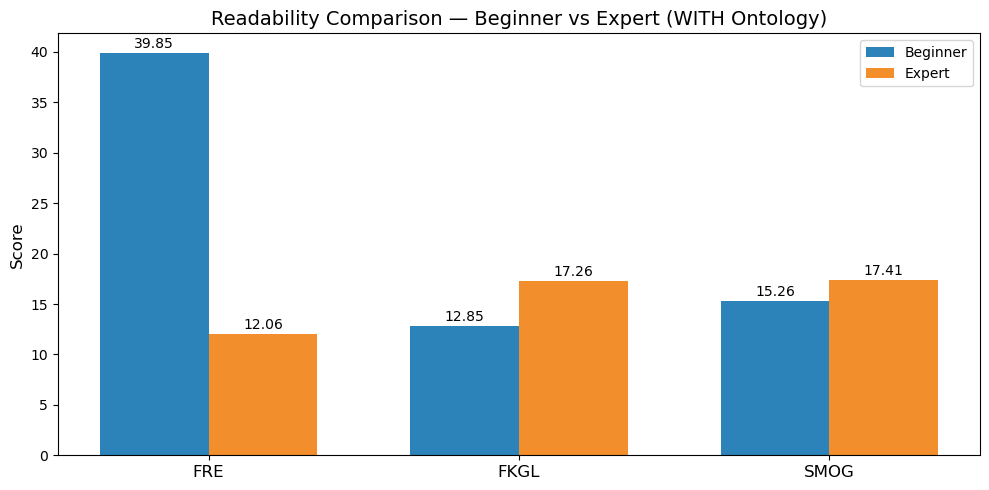

In [143]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["FRE", "FKGL", "SMOG"]
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, avg_beg_ont, width, label="Beginner", color="#2b83ba")
plt.bar(x + width/2, avg_exp_ont, width, label="Expert", color="#f28e2b")

plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Readability Comparison — Beginner vs Expert (WITH Ontology)", fontsize=14)
plt.legend()

for i, (b,e) in enumerate(zip(avg_beg_ont, avg_exp_ont)):
    plt.text(i - width/2, b + 0.5, f"{b:.2f}", ha="center")
    plt.text(i + width/2, e + 0.5, f"{e:.2f}", ha="center")

plt.tight_layout()
plt.show()


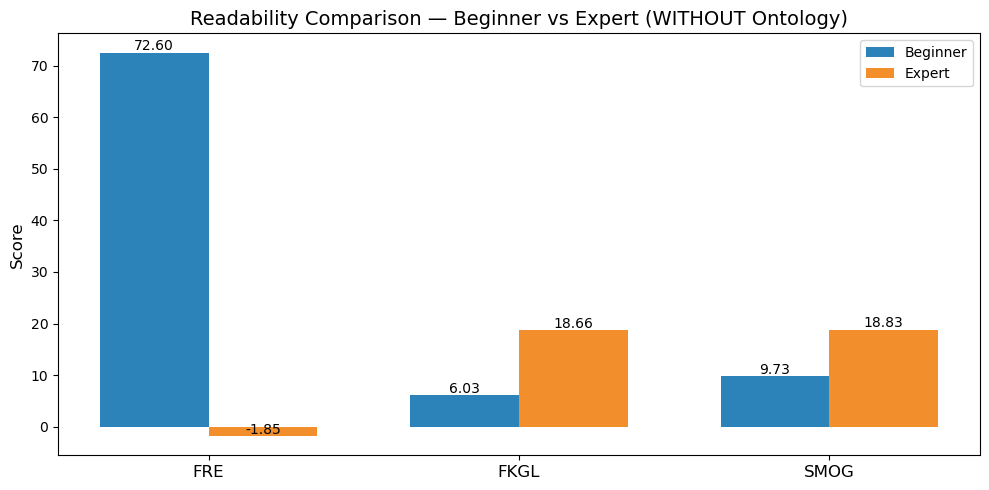

In [144]:
plt.figure(figsize=(10,5))

plt.bar(x - width/2, avg_beg_plain, width, label="Beginner", color="#2b83ba")
plt.bar(x + width/2, avg_exp_plain, width, label="Expert", color="#f28e2b")

plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Readability Comparison — Beginner vs Expert (WITHOUT Ontology)", fontsize=14)
plt.legend()

for i, (b,e) in enumerate(zip(avg_beg_plain, avg_exp_plain)):
    plt.text(i - width/2, b + 0.5, f"{b:.2f}", ha="center")
    plt.text(i + width/2, e + 0.5, f"{e:.2f}", ha="center")

plt.tight_layout()
plt.show()
